# Notebook 1: Data Preprocessing & EDA

COS40007 — Structural Defect Detection

This notebook:
1. Runs the dataset reorganisation script
2. Analyses class distribution and image statistics
3. Visualises sample images with ground-truth bounding boxes
4. Demonstrates the augmentation pipeline


In [1]:
import subprocess, sys, os
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
DATA_DIR     = PROJECT_ROOT / 'data'
DATASET_DIR  = PROJECT_ROOT / 'dataset'
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'

CLASSES = ['cracks', 'spalling', 'corrosion', 'potholes', 'paint_degradation']
CLASS_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

print('Project root:', PROJECT_ROOT)

Project root: C:\dev\ai_for_engineering


## 1. Run Reorganisation Script


In [2]:
result = subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / '01_reorganize_data.py')],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Clearing existing data/…
  Cleared and recreated data/images/* and data/labels/*

=== Wall-Crack dataset ===
  Images used: 959  |  {'train': 671, 'val': 144, 'test': 144}

=== Road-Damage dataset ===
  Images used: 1657  |  {'train': 1159, 'val': 249, 'test': 249}

=== Concrete-Structural dataset ===
  Images used: 2010  |  {'train': 1407, 'val': 301, 'test': 302}

=== Total images reorganised: 4626 ===
  Written: C:\dev\ai_for_engineering\data\data.yaml
  Written: C:\dev\ai_for_engineering\data\manifest.csv

=== Class distribution (train labels) ===
  cracks              :  3439 bounding boxes
  spalling            :   236 bounding boxes
  corrosion           :   267 bounding boxes
  potholes            :   883 bounding boxes
  paint_degradation   :   304 bounding boxes

=== Split totals ===
  train: 3237 images, 3237 label files
  val: 694 images, 694 label files
  test: 695 images, 695 label files



## 2. Dataset Statistics


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

def count_bbox_per_class(split: str) -> dict:
    lbl_dir = DATA_DIR / 'labels' / split
    counts = {c: 0 for c in CLASSES}
    for lbl in lbl_dir.glob('*.txt'):
        for line in lbl.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                cls = int(parts[0])
                if 0 <= cls < len(CLASSES):
                    counts[CLASSES[cls]] += 1
    return counts

def count_images(split: str) -> int:
    return len(list((DATA_DIR / 'images' / split).glob('*.jpg')))

# Summary table
rows = []
for split in ('train', 'val', 'test'):
    bbox_counts = count_bbox_per_class(split)
    row = {'split': split, 'images': count_images(split), **bbox_counts}
    rows.append(row)

df = pd.DataFrame(rows).set_index('split')
print(df.to_string())

       images  cracks  spalling  corrosion  potholes  paint_degradation
split                                                                  
train    2591    3439       236        267       883                304
val       557     777        57         60       177                 58
test      555     753        57         53       201                 58


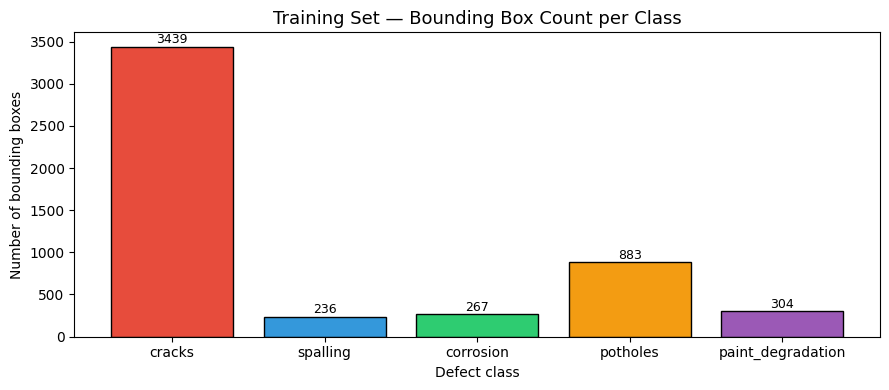

In [4]:
# Class distribution bar chart
train_counts = count_bbox_per_class('train')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASSES, [train_counts[c] for c in CLASSES], color=CLASS_COLORS, edgecolor='black')
ax.set_title('Training Set — Bounding Box Count per Class', fontsize=13)
ax.set_ylabel('Number of bounding boxes')
ax.set_xlabel('Defect class')
for bar, c in zip(bars, CLASSES):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(train_counts[c]), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'runs' / 'class_distribution.png'), dpi=150)
plt.show()

## 3. Sample Image Visualisation


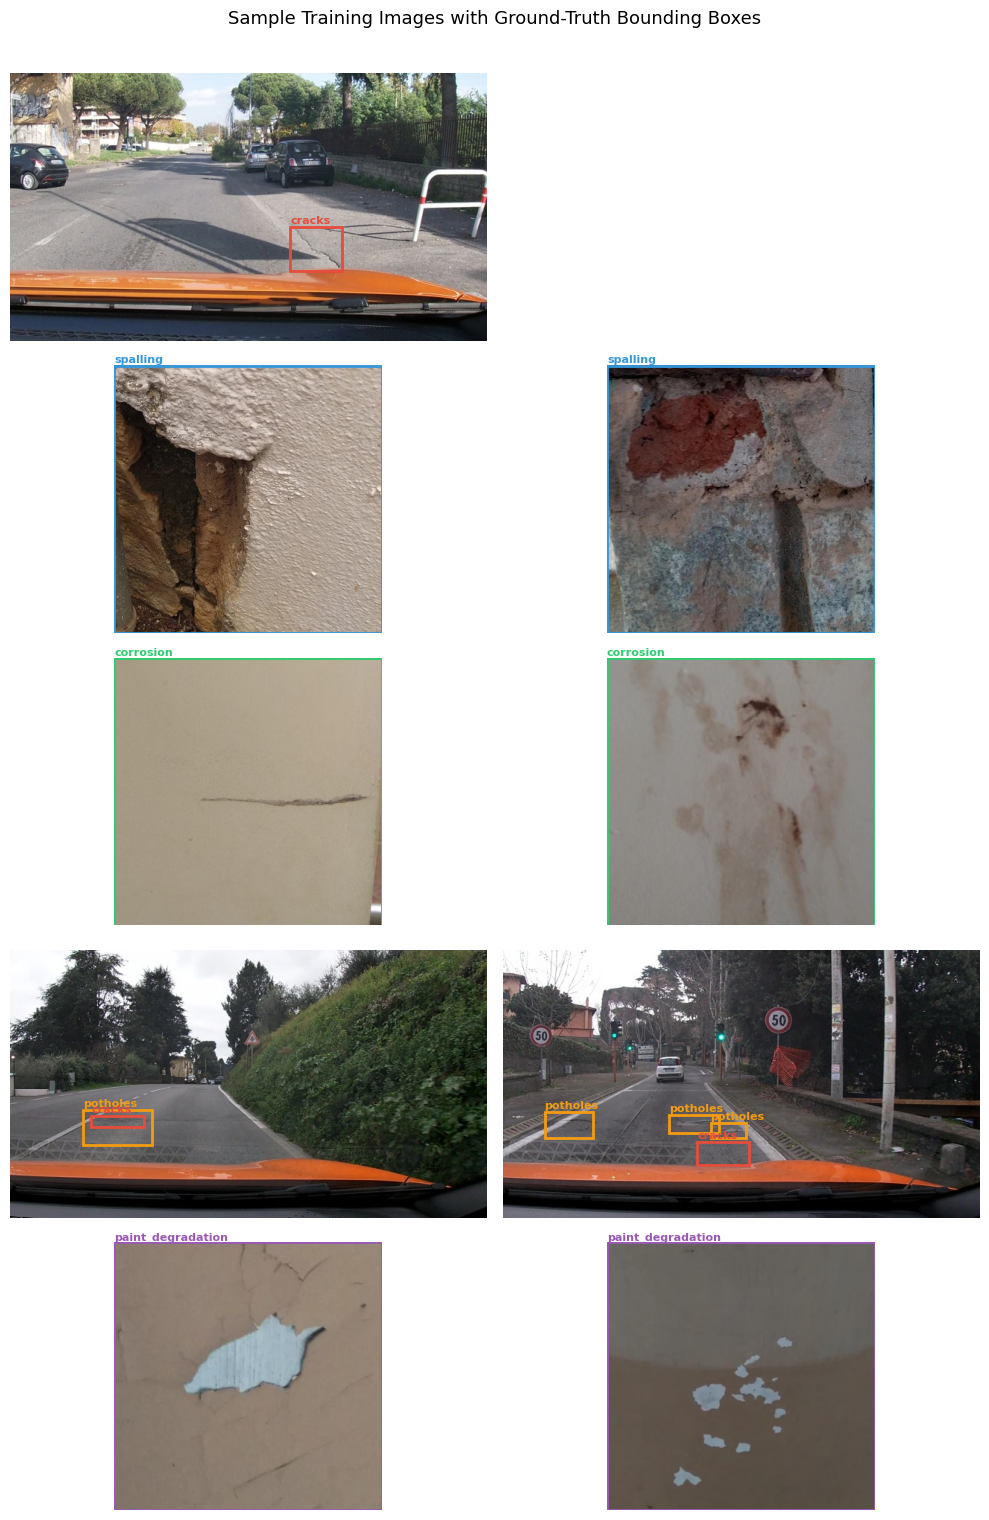

In [5]:
def draw_bboxes(ax, img: Image.Image, label_path: Path):
    """Draws YOLO-format bboxes on a matplotlib axes."""
    w, h = img.size
    ax.imshow(img)
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=CLASS_COLORS[cls], facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, CLASSES[cls], color=CLASS_COLORS[cls],
                    fontsize=8, fontweight='bold')
    ax.axis('off')


# Show 2 random samples per class from train split
img_dir = DATA_DIR / 'images' / 'train'
lbl_dir = DATA_DIR / 'labels' / 'train'

# Group label files by dominant class
class_images = {c: [] for c in range(len(CLASSES))}
for lbl in lbl_dir.glob('*.txt'):
    text = lbl.read_text().strip()
    if not text:
        continue
    first_cls = int(text.split()[0])
    if first_cls < len(CLASSES):
        class_images[first_cls].append(lbl.stem)

fig, axes = plt.subplots(len(CLASSES), 2, figsize=(10, 3 * len(CLASSES)))
np.random.seed(0)
for cls_idx, cls_name in enumerate(CLASSES):
    stems = class_images[cls_idx]
    np.random.shuffle(stems)
    for col, stem in enumerate(stems[:2]):
        img_path = img_dir / (stem + '.jpg')
        lbl_path = lbl_dir / (stem + '.txt')
        if img_path.exists():
            img = Image.open(img_path).convert('RGB')
            draw_bboxes(axes[cls_idx][col], img, lbl_path)
            if col == 0:
                axes[cls_idx][col].set_ylabel(cls_name, fontsize=10, rotation=0, labelpad=60, va='center')
        else:
            axes[cls_idx][col].axis('off')

plt.suptitle('Sample Training Images with Ground-Truth Bounding Boxes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'runs' / 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Image Size Distribution


In [6]:
from collections import Counter

sizes = []
for img_path in list((DATA_DIR / 'images' / 'train').glob('*.jpg'))[:500]:
    with Image.open(img_path) as im:
        sizes.append(im.size)

size_counts = Counter(sizes).most_common(10)
print('Top 10 image resolutions in training set:')
for size, count in size_counts:
    print(f'  {size[0]}x{size[1]}: {count} images')

Top 10 image resolutions in training set:
  512x512: 500 images


## 5. Augmentation Demo


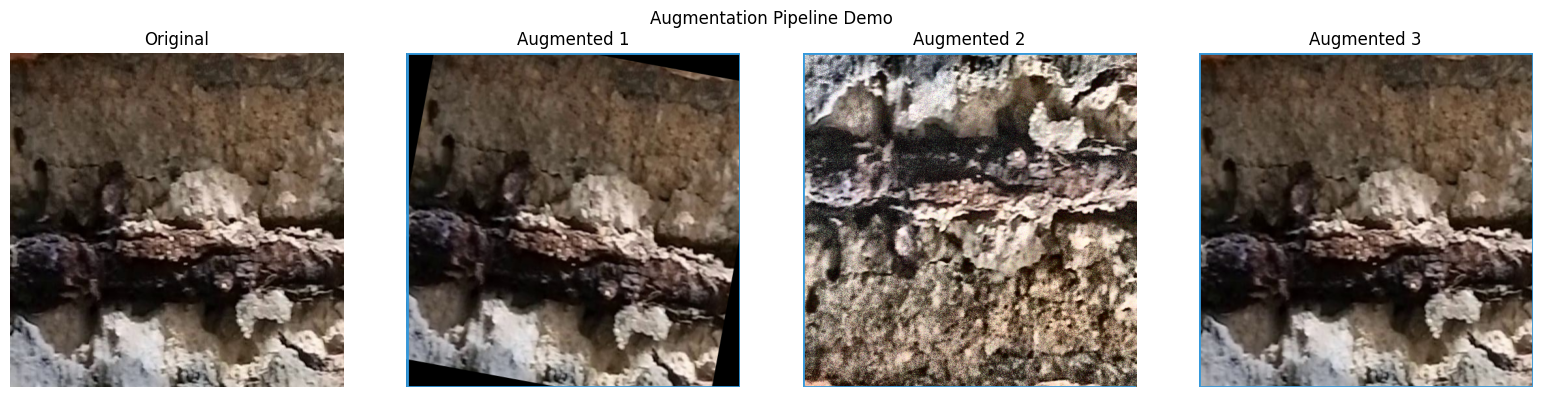

In [7]:
import importlib.util, cv2, sys
import albumentations as A

# Load augmentation module (numeric filename requires importlib)
_spec = importlib.util.spec_from_file_location("augmentation", SCRIPTS_DIR / "02_augmentation.py")
aug_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(aug_mod)

# Pick one sample image that has bboxes
sample_img = None
for _p in sorted((DATA_DIR / 'images' / 'train').glob('*.jpg')):
    _lbl = DATA_DIR / 'labels' / 'train' / (_p.stem + '.txt')
    if _lbl.exists() and _lbl.read_text().strip():
        sample_img = _p
        break
assert sample_img, 'No training images found — run reorganise script first'

sample_lbl = DATA_DIR / 'labels' / 'train' / (sample_img.stem + '.txt')
cls_ids, bboxes = aug_mod.read_yolo_labels(sample_lbl)
image = cv2.cvtColor(cv2.imread(str(sample_img)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 4):
    result    = aug_mod.AUGMENT_TRANSFORM(image=image, bboxes=bboxes, class_labels=cls_ids)
    aug_img   = result['image']
    aug_boxes = result['bboxes']
    aug_cls   = result['class_labels']
    h, w = aug_img.shape[:2]
    axes[i].imshow(aug_img)
    for cls, (cx, cy, bw, bh) in zip(aug_cls, aug_boxes):
        cls = int(cls)   # albumentations 2.x may return numpy/float class labels
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        rect = patches.Rectangle((x1, y1), bw * w, bh * h,
                                  linewidth=2, edgecolor=CLASS_COLORS[cls], facecolor='none')
        axes[i].add_patch(rect)
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle('Augmentation Pipeline Demo', fontsize=12)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'runs' / 'augmentation_demo.png'), dpi=120)
plt.show()


## 6. Run Augmentation on Training Set

Uncomment to generate 2× augmented copies of every training image.


In [8]:
# result = subprocess.run(
#     [sys.executable, str(SCRIPTS_DIR / '02_augmentation.py'), '--n', '2'],
#     capture_output=True, text=True
# )
# print(result.stdout)
print('Augmentation skipped — uncomment above cell to run.')

Augmentation skipped — uncomment above cell to run.
